<a href="https://colab.research.google.com/github/Arnav0605/Python_Projects/blob/main/Titanic_Survival_Prediction%20_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [48]:
df=pd.read_csv("train.csv")
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


<Axes: xlabel='Survived', ylabel='count'>

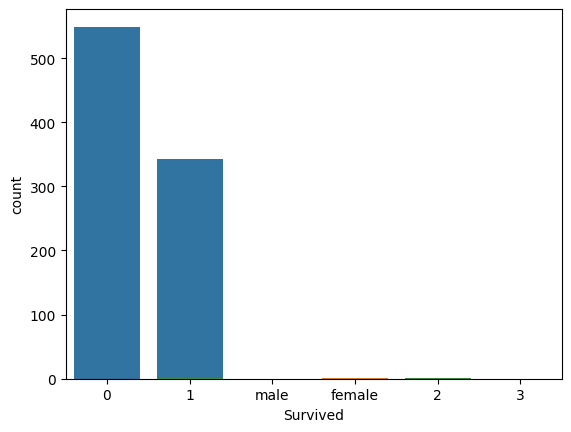

In [49]:
sns.countplot(x='Survived',data=df)
sns.barplot(x='Sex', y='Survived', data=df)
sns.barplot(x='Pclass', y='Survived', data=df)

In [50]:
df['Sex'] = df['Sex'].map({'male':0, 'female':1}).fillna(0) # Fill NaNs introduced by mapping with 0 (male)
df['Age'] = df['Age'].fillna(df['Age'].median())

# Safely get the mode for 'Embarked' or use 'S' as a fallback if mode is empty
embarked_mode = df['Embarked'].mode()
if not embarked_mode.empty:
    df['Embarked'] = df['Embarked'].fillna(embarked_mode[0])
else:
    df['Embarked'] = df['Embarked'].fillna('S') # Fallback if 'Embarked' is entirely NaN

df['Embarked'] = df['Embarked'].map({'S':0, 'C':1, 'Q':2}).fillna(0) # Fill NaNs introduced by mapping with 0 (S)

features = ['Pclass','Sex','Age','Fare','Embarked']
X = df[features]
y = df['Survived']

In [51]:
X_train,X_test,Y_train,Y_test=train_test_split(X,y,test_size=0.2,random_state=42)
print(X_train.shape,X_test.shape,Y_train.shape,Y_test.shape)

(712, 5) (179, 5) (712,) (179,)


In [52]:
models={
    "Logistic Regression":LogisticRegression(max_iter=200),
    "Random Forest":RandomForestClassifier(n_estimators=100),
    "Support Vector Machine":SVC(kernel='linear')
}
results={}
for name,model in models.items():
    model.fit(X_train.fillna(0),Y_train)
    Y_pred=model.predict(X_test.fillna(0))
    results[name]=accuracy_score(Y_test,Y_pred)

In [53]:
  for name,acc in results.items():
    print(f"{name}:{acc:.2f}")

Logistic Regression:0.79
Random Forest:0.80
Support Vector Machine:0.78


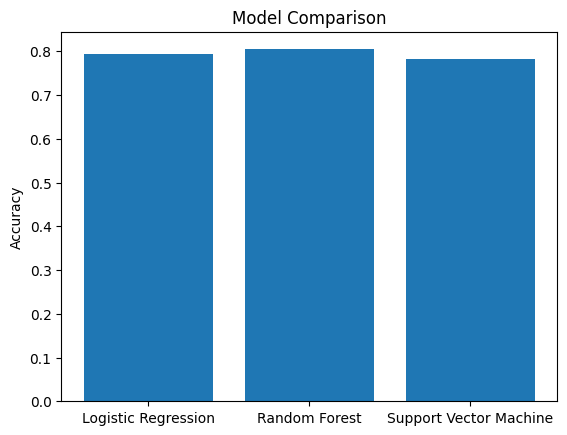

In [54]:
plt.bar(results.keys(), results.values())
plt.ylabel("Accuracy")
plt.title("Model Comparison")
plt.show()


In [46]:
best_model = RandomForestClassifier(n_estimators=100)
best_model.fit(X_train, Y_train)
y_pred = best_model.predict(X_test)

print(confusion_matrix(Y_test, y_pred))
print(classification_report(Y_test, y_pred))

[[83 22]
 [31 43]]
              precision    recall  f1-score   support

           0       0.73      0.79      0.76       105
           1       0.66      0.58      0.62        74

    accuracy                           0.70       179
   macro avg       0.69      0.69      0.69       179
weighted avg       0.70      0.70      0.70       179

